# GRK — LightGBM (Tweedie) + Residual Ordinary Kriging + NST

Pipeline:

1. Data (stations, wet days ≥ 0.5 mm, SoilGrids).
2. 80/20 stratified split by `elev_zone` (seed=42).
3. Cached geo features (`idw`, `gos`, `svd_*`) + static (`x_proj`, `y_proj`, `elevation_m`, soil).
4. LightGBM Tweedie (p=1.5).
5. Predictions + basic metrics.
6. Residual diagnostics: mean, std, skew, kurtosis, Spearman rho, Q-Q.
7. NST (Normal Score Transform): residuals -> N(0,1).
8. Pooled variogram on NST residuals, exponential model.
9. Local Ordinary Kriging (k=15) -> K=50 MC back-transform via NST inverse.
10. Comparison: LGB-only vs LGB + OK NST, CRPS.

In [14]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis, spearmanr, norm
from scipy.spatial.distance import pdist
from scipy.spatial import cKDTree
from scipy.optimize import curve_fit
from tqdm import tqdm

from pyproj import Transformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

from thesis.config import Config
from thesis.data.soilgrids import SoilGridsSource

REPO = Path('..').resolve().parent
DATA = REPO / 'data' / 'rekis'
OUT  = REPO / 'outputs' / 'grk'
OUT.mkdir(parents=True, exist_ok=True)

ELEV_BINS   = [-np.inf, 250.0, 500.0, np.inf]
ELEV_LABELS = ['plains', 'hills', 'mountains']
SOILGRIDS_VARS = ['bulk_density', 'clay', 'sand', 'silt', 'soc', 'water_10kpa']

## 1. Stations

In [15]:
stations = pd.read_csv(DATA / 'Stationsliste.txt')
stations = stations.rename(columns={
    'Stat_ID': 'station_id',
    'Laenge': 'lon', 'Breite': 'lat', 'Hoehe': 'elevation_m',
})[['station_id', 'lon', 'lat', 'elevation_m']]

tr = Transformer.from_crs('EPSG:4326', 'EPSG:3035', always_xy=True)
stations['x_proj'], stations['y_proj'] = tr.transform(stations['lon'], stations['lat'])
stations['elev_zone'] = pd.cut(stations['elevation_m'], bins=ELEV_BINS, labels=ELEV_LABELS)

print(f'stations: {len(stations):,}')

stations: 5,029


## 2. Precipitation (RR.csv -> long, wet days >= 0.5 mm, 2000-2023)

In [16]:
rr = pd.read_csv(DATA / 'RR.csv', sep=';', decimal=',', parse_dates=['zeit'])
rr = rr.rename(columns={'zeit': 'date'})
rr = rr[(rr['date'] >= '2000-01-01') & (rr['date'] <= '2023-12-31')].copy()
rr['date'] = rr['date'].dt.date

long = rr.melt(id_vars='date', var_name='station_id', value_name='precip_mm')
long = long.dropna(subset=['precip_mm'])
long = long[long['precip_mm'] >= 0.5]
long = long.merge(stations[['station_id']], on='station_id')
long = long.drop_duplicates(subset=['date', 'station_id'])

active = stations[stations['station_id'].isin(long['station_id'])].copy()
active = active.dropna(subset=['elev_zone']).drop_duplicates('station_id').reset_index(drop=True)
long = long[long['station_id'].isin(active['station_id'])].copy()

print(f'active stations: {len(active):,}')
print(f'wet station-days: {len(long):,}')

active stations: 2,462
wet station-days: 8,287,917


## 3. SoilGrids (static per-station features)

In [17]:
cfg = Config()
cfg.paths.root  = REPO / 'data'
cfg.paths.cache = REPO / 'data' / 'cache'

for v in SOILGRIDS_VARS:
    src = SoilGridsSource(cfg, variable=v, depth=None)
    active[v] = src.sample_at_projected(active['x_proj'].to_numpy(), active['y_proj'].to_numpy())

active[SOILGRIDS_VARS].describe()

,bulk_density,clay,sand,silt,soc,water_10kpa
count,2462.000000,2462.000000,2462.000000,2462.000000,2462.000000,2462.000000
mean,108.941132,165.162872,340.886261,308.052002,267.461670,-1702.466064
std,28.523119,77.168701,193.187698,142.568344,123.945030,2387.890869
min,0.000000,0.000000,0.000000,0.000000,0.000000,-10922.666992
25%,98.654152,98.805710,194.125431,181.429344,201.157890,-2639.504456
50%,117.248993,165.465576,280.860855,327.243240,247.772758,-834.077850
75%,128.681164,231.399345,485.237633,433.840004,306.232346,38.220163
max,150.153625,368.024414,810.971924,662.842041,933.442871,447.093781


## 4. 80/20 stratified split (by elev_zone, seed=42)

In [18]:
train_sids, val_sids = train_test_split(
    active['station_id'].to_numpy(),
    test_size=0.2, random_state=42,
    stratify=active['elev_zone'].astype(str).to_numpy(),
)
train_set, val_set = set(train_sids), set(val_sids)
print(f'train stations: {len(train_set):,}   val stations: {len(val_set):,}')

train stations: 1,969   val stations: 493


## 5. Geo features from cache + train/val matrices

Cache `outputs/grk/hparam_features_train80.parquet` is pre-computed (`idw`, `gos`, `svd_00..svd_20`).

In [19]:
feats = pd.read_parquet(OUT / 'hparam_features_train80.parquet')

FEATURE_COLS = (
    ['idw', 'gos']
    + [f'svd_{i:02d}' for i in range(21)]
    + ['x_proj', 'y_proj', 'elevation_m']
    + SOILGRIDS_VARS
)

df = feats.merge(
    active[['station_id', 'x_proj', 'y_proj', 'elevation_m'] + SOILGRIDS_VARS],
    on='station_id',
)
df['date'] = pd.to_datetime(df['date']).dt.date
df = df.merge(long[['date', 'station_id', 'precip_mm']], on=['date', 'station_id'])
df = df.dropna(subset=FEATURE_COLS)
df['split'] = np.where(df['station_id'].isin(train_set), 'train', 'val')

train = df[df['split'] == 'train'].copy()
val   = df[df['split'] == 'val'].copy()
X_tr, y_tr = train[FEATURE_COLS], train['precip_mm']
X_va, y_va = val[FEATURE_COLS],   val['precip_mm']
print(f'train rows: {len(X_tr):,}   val rows: {len(X_va):,}   features: {len(FEATURE_COLS)}')

train rows: 6,620,310   val rows: 1,666,528   features: 32


## 6. LightGBM (Tweedie, p=1.5)

In [20]:
params = dict(
    objective='tweedie',
    tweedie_variance_power=1.5,
    metric=['tweedie', 'l1'],
    n_estimators=2000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=1,
    verbosity=-1,
    random_state=42,
)

model = LGBMRegressor(**params)
t0 = time.time()
model.fit(
    X_tr, y_tr,
    eval_set=[(X_va, y_va)],
    callbacks=[early_stopping(50, first_metric_only=True), log_evaluation(100)],
)
print(f'fit: {time.time()-t0:.1f}s   best_iter: {model.best_iteration_}')

Training until validation scores don't improve for 50 rounds
[100]	valid_0's tweedie: 7.85736	valid_0's l1: 0.798245
[200]	valid_0's tweedie: 7.85648	valid_0's l1: 0.790927
[300]	valid_0's tweedie: 7.85632	valid_0's l1: 0.790092
[400]	valid_0's tweedie: 7.85623	valid_0's l1: 0.789834
[500]	valid_0's tweedie: 7.8562	valid_0's l1: 0.789586
Early stopping, best iteration is:
[477]	valid_0's tweedie: 7.85619	valid_0's l1: 0.789524
Evaluated only: tweedie
fit: 85.9s   best_iter: 477


## 7. Predictions and basic metrics

In [21]:
y_pred = np.clip(model.predict(X_va), 0.0, None)

metrics = {
    'RMSE': np.sqrt(mean_squared_error(y_va, y_pred)),
    'MAE':  mean_absolute_error(y_va, y_pred),
    'R²':   r2_score(y_va, y_pred),
}
for k, v in metrics.items():
    print(f'{k:5s}  {v:.3f}')

RMSE   1.713
MAE    0.790
R²     0.920


## 8. Residual diagnostics

Conditions for applying Ordinary Kriging to residuals:

1. `mean(resid) ~ 0` — no global bias.
2. `|skew| < 1`, excess `kurtosis < 3` — close to normal.
3. Homoscedasticity: Spearman rho between decile mean prediction and decile std of residuals should be `< 0.4`.
4. Q-Q plot against N(0, sigma^2) — points on the diagonal.

In [22]:
resid = y_va.values - y_pred  # observed minus trend

# Heteroscedasticity: prediction deciles vs std of residuals
deciles = pd.qcut(y_pred, 10, labels=False, duplicates='drop')
by_decile = pd.DataFrame({'pred': y_pred, 'resid': resid, 'd': deciles}).groupby('d').agg(
    mean_pred=('pred', 'mean'), std_resid=('resid', 'std'), n=('resid', 'size'),
)
rho, p_rho = spearmanr(by_decile['mean_pred'], by_decile['std_resid'])

print(f'mean      = {resid.mean():+.3f} mm')
print(f'std       = {resid.std():.3f} mm')
print(f'skew      = {skew(resid):+.3f}')
print(f'kurtosis  = {kurtosis(resid):+.3f}   (excess; <3 is good)')
print(f'Spearman rho(mean_pred, std_resid) = {rho:+.3f}   (p={p_rho:.3g}; <0.4 = homoscedastic)')
print()
print(by_decile.round(3))

mean      = +0.003 mm
std       = 1.713 mm
skew      = +4.638
kurtosis  = +173.875   (excess; <3 is good)
Spearman rho(mean_pred, std_resid) = +1.000   (p=6.65e-64; <0.4 = homoscedastic)

   mean_pred  std_resid       n
d                              
0      0.753      0.395  166653
1      1.022      0.547  166653
2      1.404      0.693  166653
3      1.911      0.812  166652
4      2.552      0.999  166653
5      3.383      1.162  166653
6      4.496      1.379  166652
7      6.111      1.696  166653
8      8.847      2.139  166653
9     18.339      4.007  166653


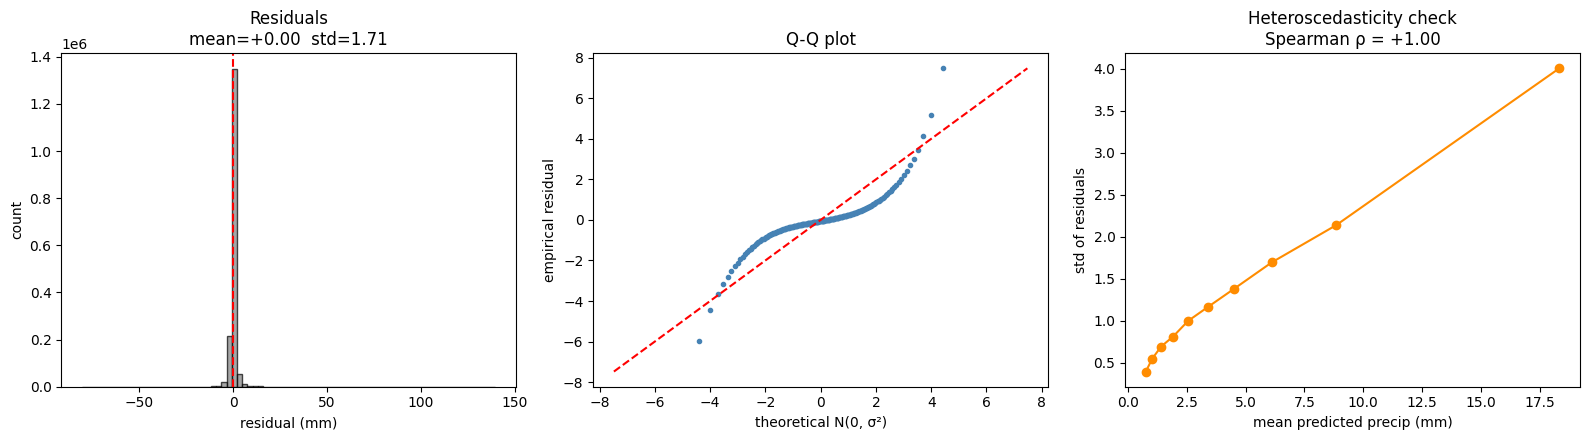

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Residual histogram
axes[0].hist(resid, bins=80, color='gray', edgecolor='black', alpha=0.7)
axes[0].axvline(0, color='red', ls='--')
axes[0].set_xlabel('residual (mm)'); axes[0].set_ylabel('count')
axes[0].set_title(f'Residuals\nmean={resid.mean():+.2f}  std={resid.std():.2f}')

# (b) Q-Q plot against N(0, sigma^2)
qs = np.linspace(0.005, 0.995, 200)
theor = norm.ppf(qs, loc=0, scale=resid.std())
emp   = np.quantile(resid, qs)
axes[1].plot(theor, emp, 'o', ms=3, color='steelblue')
lim = max(abs(theor).max(), abs(emp).max())
axes[1].plot([-lim, lim], [-lim, lim], 'r--')
axes[1].set_xlabel('theoretical N(0, sigma^2)'); axes[1].set_ylabel('empirical residual')
axes[1].set_title('Q-Q plot')

# (c) Std of residuals by prediction deciles
axes[2].plot(by_decile['mean_pred'], by_decile['std_resid'], 'o-', color='darkorange')
axes[2].set_xlabel('mean predicted precip (mm)'); axes[2].set_ylabel('std of residuals')
axes[2].set_title(f'Heteroscedasticity check\nSpearman rho = {rho:+.2f}')

plt.tight_layout(); plt.show()

## 9. Pooled variogram on TRAIN residuals

In [24]:
# TRAIN residuals for variogram and kriging; VAL residuals for diagnostics
y_pred_tr = np.clip(model.predict(X_tr), 0.0, None)
train_diag = train[['date', 'station_id', 'x_proj', 'y_proj', 'precip_mm']].copy()
train_diag['trend']    = y_pred_tr
train_diag['residual'] = train_diag['precip_mm'] - train_diag['trend']
train_diag['date']     = pd.to_datetime(train_diag['date'])

val_diag = val[['date', 'station_id', 'x_proj', 'y_proj', 'precip_mm']].copy()
val_diag['trend']    = y_pred
val_diag['residual'] = val_diag['precip_mm'] - val_diag['trend']
val_diag['date']     = pd.to_datetime(val_diag['date'])

# NST: map train residuals -> N(0,1); fit only on train to avoid leakage
def nst_fit(x):
    x = np.sort(x)
    n = len(x)
    p = (np.arange(1, n + 1) - 0.375) / (n + 0.25)
    return x, norm.ppf(p)

def nst_fwd(x, ref_vals, ref_norms):
    return np.interp(x, ref_vals, ref_norms)

def nst_inv(z, ref_vals, ref_norms):
    return np.interp(z, ref_norms, ref_vals)

nst_ref_vals, nst_ref_norms = nst_fit(train_diag['residual'].to_numpy())
train_diag['residual_nst'] = nst_fwd(train_diag['residual'].to_numpy(), nst_ref_vals, nst_ref_norms)

print(f'train_diag: {len(train_diag):,}   val_diag: {len(val_diag):,}')
print(f'NST check:  mean={train_diag["residual_nst"].mean():+.3f}  std={train_diag["residual_nst"].std():.3f}  (~ 0, ~ 1)')

train_diag: 6,620,310   val_diag: 1,666,528
NST check:  mean=+0.000  std=1.000  (≈ 0, ≈ 1)


In [25]:
def pooled_variogram(df, value_col, max_dist_km=500.0, n_lags=20):
    """Pooled empirical semi-variance across all days."""
    edges   = np.linspace(0, max_dist_km * 1000.0, n_lags + 1)
    sum_sqd = np.zeros(n_lags)
    counts  = np.zeros(n_lags, dtype=np.int64)
    for _, sub in df.groupby('date'):
        coords = sub[['x_proj', 'y_proj']].to_numpy()
        vals   = sub[value_col].to_numpy()
        if len(coords) < 2:
            continue
        dists = pdist(coords)
        sqd   = pdist(vals.reshape(-1, 1), metric='sqeuclidean')
        bin_idx = np.searchsorted(edges, dists, side='right') - 1
        valid = (bin_idx >= 0) & (bin_idx < n_lags)
        np.add.at(sum_sqd, bin_idx[valid], sqd[valid])
        np.add.at(counts,  bin_idx[valid], 1)
    gamma = 0.5 * sum_sqd / counts
    centers_km = (edges[:-1] + edges[1:]) / 2 / 1000.0
    return centers_km, gamma, counts

t0 = time.time()
h_emp, g_emp, n_pairs = pooled_variogram(train_diag, 'residual')
print(f'variogram: {time.time()-t0:.1f}s   total pairs: {n_pairs.sum():,}')

variogram: 118.4s   total pairs: 4,634,729,716


exponential: nugget=2.815  psill=0.718  range=500.0 km  sill=3.533


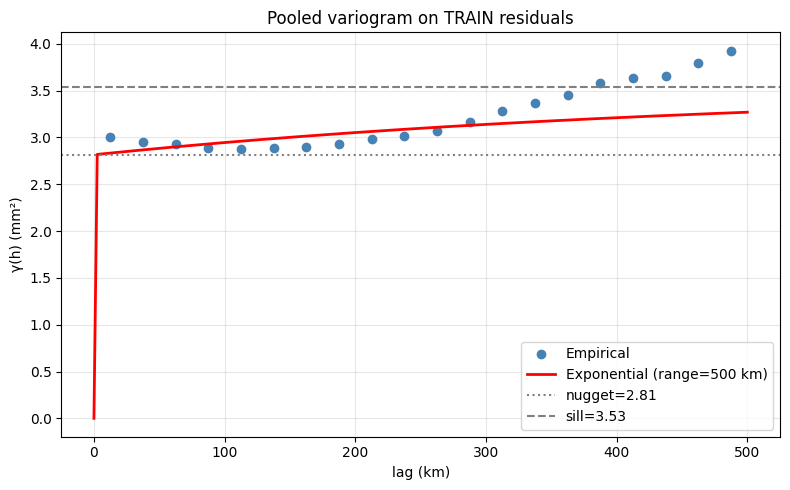

In [28]:
def exponential(h, c0, c, a):
    h = np.asarray(h, dtype=float)
    out = np.zeros_like(h)
    m = h > 0
    out[m] = c0 + c * (1.0 - np.exp(-h[m] / a))
    return out

# Fit on the rising part (<= 350 km; beyond that domain edge effects dominate)
valid = ~np.isnan(g_emp) & (h_emp <= 350)
p0 = [g_emp[valid][0], g_emp[valid].max() - g_emp[valid][0], 50.0]
popt, _ = curve_fit(
    exponential, h_emp[valid], g_emp[valid], p0=p0, maxfev=5000,
    bounds=([0.0, 0.0, 1.0], [g_emp[valid].max() * 2, g_emp[valid].max() * 5, 500.0]),
)
nugget, partial_sill, range_km = popt
sill = nugget + partial_sill
print(f'exponential: nugget={nugget:.3f}  psill={partial_sill:.3f}  range={range_km:.1f} km  sill={sill:.3f}')

def vgm_fn(h_meters):
    return exponential(np.asarray(h_meters) / 1000.0, nugget, partial_sill, range_km)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(h_emp, g_emp, 'o', color='steelblue', label='Empirical', ms=6)
hh = np.linspace(0, 500, 200)
ax.plot(hh, exponential(hh, nugget, partial_sill, range_km), '-', color='red', lw=2,
        label=f'Exponential (range={range_km:.0f} km)')
ax.axhline(nugget, color='gray', ls=':', label=f'nugget={nugget:.2f}')
ax.axhline(sill, color='gray', ls='--', label=f'sill={sill:.2f}')
ax.set_xlabel('lag (km)'); ax.set_ylabel('gamma(h) (mm^2)')
ax.set_title('Pooled variogram on TRAIN residuals')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Text(0, 0.5, 'count')

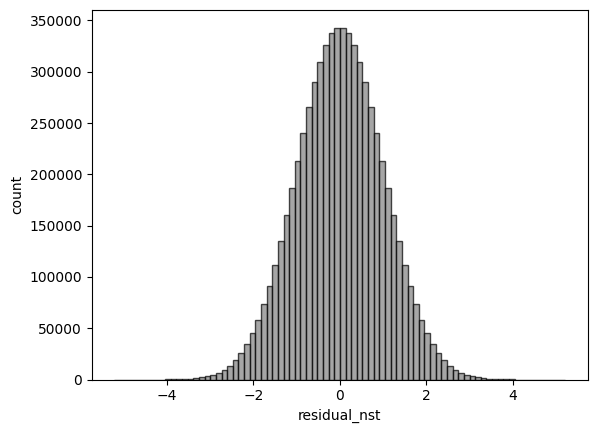

In [35]:
train_diag['residual_nst'].plot.hist(bins=80, color='gray', edgecolor='black', alpha=0.7)
plt.xlabel('residual_nst'); plt.ylabel('count')

In [36]:
def ok_local(coords_tr, z_tr, coords_val, vgm_fn, k=15, ridge=1e-6):
    """Vectorised local Ordinary Kriging. Returns (prediction, kriging_variance)."""
    k = min(k, len(coords_tr))
    tree = cKDTree(coords_tr)
    distances, indices = tree.query(coords_val, k=k)
    nbr_coords = coords_tr[indices]
    diff = nbr_coords[:, :, None, :] - nbr_coords[:, None, :, :]
    nbr_h = np.linalg.norm(diff, axis=-1)
    n_val = len(coords_val)
    A = np.ones((n_val, k + 1, k + 1))
    A[:, :k, :k] = vgm_fn(nbr_h) + ridge * np.eye(k)
    A[:, k, k] = 0.0
    b = np.empty((n_val, k + 1))
    b[:, :k] = vgm_fn(distances)
    b[:, k]  = 1.0
    w = np.linalg.solve(A, b[..., None])[..., 0]
    pred   = np.einsum('ij,ij->i', w[:, :k], z_tr[indices])
    sigma2 = np.clip(np.einsum('ij,ij->i', w, b), 0.0, None)
    return pred, sigma2

In [ ]:
K_MC         = 50
K_NEIGHBOURS = 50

val_days = sorted(val_diag['date'].unique())
print(f'kriging on {len(val_days)} val days')

rng_mc = np.random.default_rng(0)
train_by_date = dict(tuple(train_diag.groupby('date')))
val_by_date   = dict(tuple(val_diag.groupby('date')))

all_true, all_trend, all_pred, all_samples = [], [], [], []
t0 = time.time()
for d in tqdm(val_days, desc='OK + NST per day'):
    tr = train_by_date[d]
    vl = val_by_date[d]
    krig_nst, sigma2_k = ok_local(
        tr[['x_proj', 'y_proj']].to_numpy(),
        tr['residual_nst'].to_numpy(),
        vl[['x_proj', 'y_proj']].to_numpy(),
        vgm_fn, k=K_NEIGHBOURS,
    )
    # K_MC samples from N(krig_nst, sigma2_k) -> back-transform -> precip
    noise = rng_mc.standard_normal((len(krig_nst), K_MC))
    samples_nst   = krig_nst[:, None] + np.sqrt(sigma2_k)[:, None] * noise
    samples_resid = nst_inv(samples_nst.ravel(), nst_ref_vals, nst_ref_norms).reshape(samples_nst.shape)
    samples_precip = np.clip(vl['trend'].to_numpy()[:, None] + samples_resid, 0.0, None)

    all_true.append(vl['precip_mm'].to_numpy())
    all_trend.append(vl['trend'].to_numpy())
    all_pred.append(samples_precip.mean(axis=1))
    all_samples.append(samples_precip)

y_t        = np.concatenate(all_true)
y_p_lgb    = np.concatenate(all_trend)
y_p_full   = np.concatenate(all_pred)
samples_all = np.concatenate(all_samples)   # (n_total, K_MC)
print(f'kriging: {time.time()-t0:.1f}s   rows: {len(y_t):,}')

kriging on 7535 val days


OK + NST per day: 100%|██████████| 7535/7535 [02:04<00:00, 60.67it/s] 


kriging: 124.6s   rows: 1,666,528


In [39]:
heavy = y_t >= 20.0

def point_metrics(yt, yp):
    return dict(
        RMSE=np.sqrt(mean_squared_error(yt, yp)),
        MAE=mean_absolute_error(yt, yp),
        R2=r2_score(yt, yp),
        MAE_heavy=mean_absolute_error(yt[heavy], yp[heavy]),
        bias_heavy=np.mean(yp[heavy] - yt[heavy]),
    )

def mean_crps(samples, obs):
    """Energy-score CRPS from K ensemble samples (O(n*K*log K))."""
    mae = np.abs(samples - obs[:, None]).mean(axis=1)
    s = np.sort(samples, axis=1)
    K = samples.shape[1]
    weights = (2 * np.arange(K) - K + 1) / K**2
    spread = (s * weights).sum(axis=1)
    return (mae - spread).mean()

cmp = pd.DataFrame({
    'LGB-only':     point_metrics(y_t, y_p_lgb),
    'LGB + OK NST': point_metrics(y_t, y_p_full),
})
cmp['Δ'] = cmp['LGB + OK NST'] - cmp['LGB-only']
print(cmp.round(3).to_string())
print()
# LGB-only has no distribution -> CRPS reduces to MAE (delta function)
crps_lgb = mean_absolute_error(y_t, y_p_lgb)
crps_ok  = mean_crps(samples_all, y_t)
print(f'CRPS LGB-only      = {crps_lgb:.4f}   (point pred = delta, CRPS = MAE)')
print(f'CRPS LGB + OK NST  = {crps_ok:.4f}')

            LGB-only  LGB + OK NST      Δ
RMSE           1.713         2.993  1.279
MAE            0.790         2.272  1.482
R2             0.920         0.757 -0.164
MAE_heavy      3.964         4.246  0.281
bias_heavy    -2.021        -0.179  1.842

CRPS LGB-only      = 0.7895   (point pred = delta, CRPS = MAE)
CRPS LGB + OK NST  = 0.8340


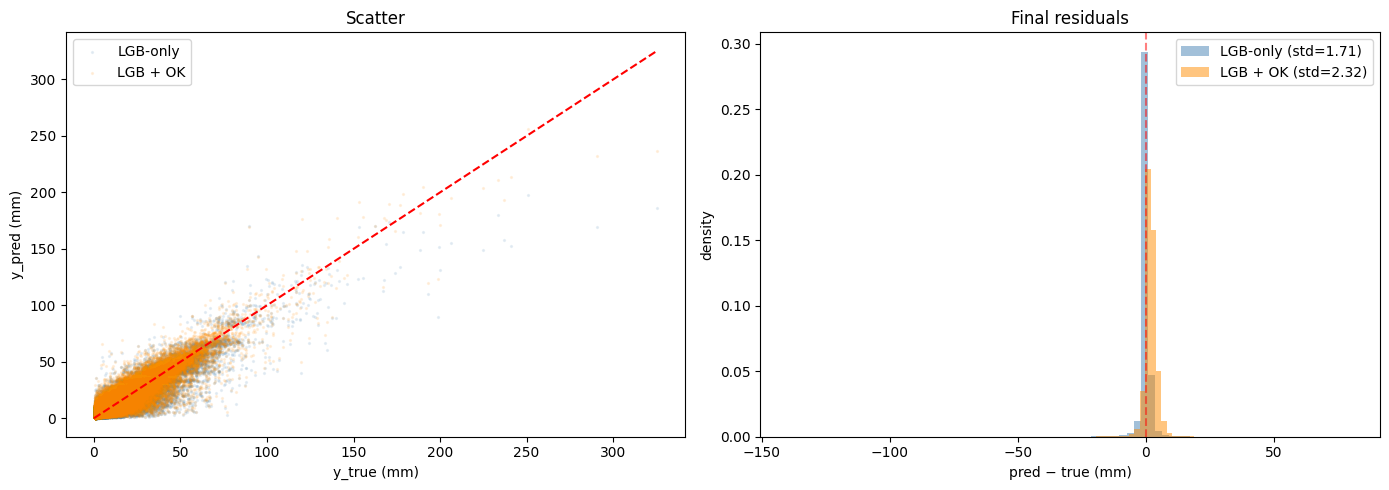

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lim = max(y_t.max(), y_p_full.max(), y_p_lgb.max())
axes[0].scatter(y_t, y_p_lgb,  s=2, alpha=0.10, label='LGB-only', color='steelblue')
axes[0].scatter(y_t, y_p_full, s=2, alpha=0.10, label='LGB + OK', color='darkorange')
axes[0].plot([0, lim], [0, lim], 'r--')
axes[0].set_xlabel('y_true (mm)'); axes[0].set_ylabel('y_pred (mm)')
axes[0].set_title('Scatter')
axes[0].legend()

r_lgb  = y_p_lgb  - y_t
r_full = y_p_full - y_t
axes[1].hist(r_lgb,  bins=80, alpha=0.5, color='steelblue',  density=True, label=f'LGB-only (std={r_lgb.std():.2f})')
axes[1].hist(r_full, bins=80, alpha=0.5, color='darkorange', density=True, label=f'LGB + OK (std={r_full.std():.2f})')
axes[1].axvline(0, color='red', ls='--', alpha=0.5)
axes[1].set_xlabel('pred − true (mm)'); axes[1].set_ylabel('density')
axes[1].set_title('Final residuals')
axes[1].legend()

plt.tight_layout(); plt.show()